<a href="https://colab.research.google.com/github/vishalmahor886/basic_ML_code/blob/main/radom_sample_imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("yasserh/titanic-dataset")

Using Colab cache for faster access to the 'titanic-dataset' dataset.


In [ ]:
import os

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
titanic = pd.read_csv(os.path.join(path, "Titanic-Dataset.csv"), usecols=['Age', 'Fare', 'Survived'])

In [ ]:
titanic.sample(5)

,Survived,Age,Fare
375,1,NaN,82.1708
697,1,NaN,7.7333
189,0,36.0,7.8958
596,1,NaN,33.0000
714,0,52.0,13.0000


In [ ]:
titanic.isnull().mean()*100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [ ]:
# train test split
from sklearn.model_selection import train_test_split


In [ ]:
x=titanic.drop(columns=['Survived'])
y=titanic['Survived']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [ ]:
x_train.shape, x_test.shape

((712, 2), (179, 2))

In [ ]:
x_train['Age_imputed'] = x_train['Age']
x_test['Age_imputed'] = x_test['Age']

In [ ]:
x_train.sample(5)

,Age,Fare,Age_imputed
106,21.0,7.6500,21.0
226,19.0,10.5000,19.0
550,17.0,110.8833,17.0
689,15.0,211.3375,15.0
801,31.0,26.2500,31.0


In [ ]:
x_train['Age_imputed'][x_train['Age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
x_test['Age_imputed'][x_test['Age_imputed'].isnull()] = x_test['Age'].dropna().sample(x_test['Age'].isnull().sum()).values

/tmp/ipython-input-1258921994.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['Age_imputed'][x_train['Age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
/tmp/ipython-input-1258921994.py

In [ ]:
x_train

,Age,Fare,Age_imputed
140,NaN,15.2458,22.0
439,31.0,10.5000,31.0
817,31.0,37.0042,31.0
378,20.0,4.0125,20.0
491,21.0,7.2500,21.0
...,...,...,...
835,39.0,83.1583,39.0
192,19.0,7.8542,19.0
629,NaN,7.7333,35.0
559,36.0,17.4000,36.0


/tmp/ipython-input-3960422558.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'], label='orginal', color='blue', hist=False)
/tmp/ipython-input-3960422558.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age_imputed'], label='Random Imputed', color='

<Axes: xlabel='Age_imputed', ylabel='Density'>

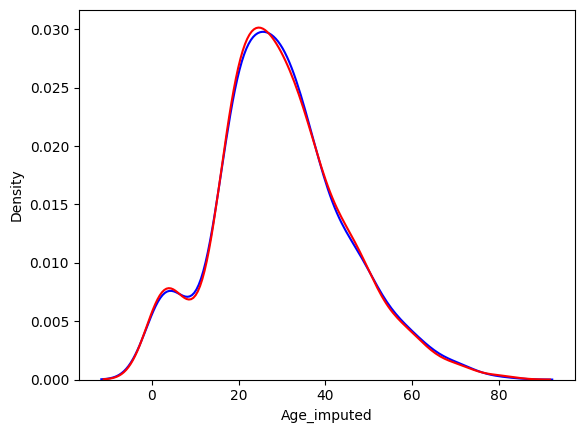

In [ ]:
sns.distplot(x_train['Age'], label='orginal', color='blue', hist=False)
sns.distplot(x_train['Age_imputed'], label='Random Imputed', color='Red', hist=False)

In [ ]:
## Variance
print(x_train['Age'].var())

print(x_train['Age_imputed'].var())

213.7165085187578
213.70965386858217


In [ ]:
x_train.cov()

,Age,Fare,Age_imputed
Age,213.716509,79.072379,213.716509
Fare,79.072379,2513.549265,66.604526
Age_imputed,213.716509,66.604526,213.709654


<Axes: >

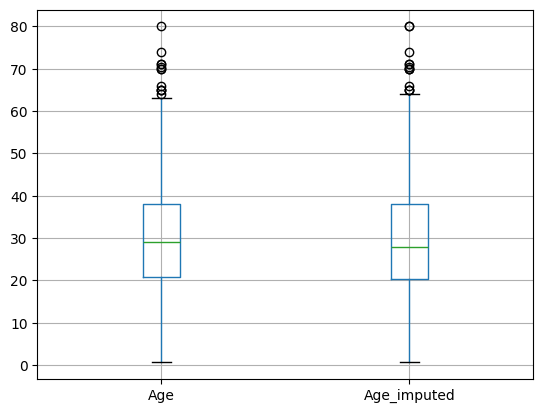

In [ ]:
x_train[['Age', 'Age_imputed']].boxplot()

In [ ]:
#

# For Categorical data

In [ ]:

url = "https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day37-handling-missing-categorical-data/train.csv"

data = pd.read_csv(url, usecols=['FireplaceQu', 'GarageQual', 'SalePrice'])

In [ ]:
data.sample(5
            )

,FireplaceQu,GarageQual,SalePrice
941,TA,TA,214000
796,TA,TA,143500
934,Gd,TA,242000
1058,Gd,TA,335000
292,Gd,TA,131000


In [ ]:
data.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [ ]:
x = data
y = data['SalePrice']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=0)

In [ ]:
x_train['GarageQual_imputed'] = x_train['GarageQual']
x_test['GarageQual_imputed'] = x_test['GarageQual']

x_train['FireplaceQu_imputed'] = x_train['FireplaceQu']
x_test['FireplaceQu_imputed'] = x_test['FireplaceQu']



In [ ]:
x_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
749,NaN,TA,98000,TA,Gd
614,NaN,NaN,75500,TA,Gd
1111,Gd,TA,205000,TA,Gd
78,NaN,NaN,136500,TA,Gd
560,Gd,TA,121500,TA,Gd


In [ ]:
x_train['GarageQual_imputed'][x_train['GarageQual_imputed'].isnull()] = x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnull().sum()).values
x_test['GarageQual_imputed'][x_test['GarageQual_imputed'].isnull()] = x_test['GarageQual'].dropna().sample(x_test['GarageQual'].isnull().sum()).values

/tmp/ipython-input-2894951916.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train['GarageQual_imputed'][x_train['GarageQual_imputed'].isnull()] = x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnull().sum()).values
/tmp/ipython-input-2894951916.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexe

In [ ]:
x_train['FireplaceQu_imputed'][x_train['FireplaceQu_imputed'].isnull()] = x_train['FireplaceQu'].dropna().sample(x_train['FireplaceQu'].isnull().sum()).values
x_test['FireplaceQu_imputed'][x_test['FireplaceQu_imputed'].isnull()] = x_test['FireplaceQu'].dropna().sample(x_test['FireplaceQu'].isnull().sum()).values

/tmp/ipython-input-3848192483.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['FireplaceQu_imputed'][x_train['FireplaceQu_imputed'].isnull()] = x_train['FireplaceQu'].dropna().sample(x_train['FireplaceQu'].isnull().sum()).values


In [ ]:
x_train.isnull().mean()

,0
FireplaceQu,0.471747
GarageQual,0.049658
SalePrice,0.000000
GarageQual_imputed,0.000000
FireplaceQu_imputed,0.000000


In [ ]:
temp = pd.concat([
    x_train['GarageQual'].value_counts() / len(x_train['GarageQual'].dropna()),
    x_train['GarageQual_imputed'].value_counts() / len(x_train)
], axis=1)
temp.columns=['original', 'imputed']
temp


,original,imputed
TA,0.950450,0.952055
Fa,0.036036,0.035103
Gd,0.009009,0.008562
Po,0.002703,0.002568
Ex,0.001802,0.001712


In [ ]:
temp = pd.concat([
    x_train['FireplaceQu'].value_counts() / len(x_train['FireplaceQu'].dropna()),
    x_train['FireplaceQu_imputed'].value_counts() / len(x_train)
], axis=1)
temp.columns=['original', 'imputed']
temp


,original,imputed
Gd,0.478120,0.477740
TA,0.416532,0.420377
Fa,0.047002,0.047089
Ex,0.030794,0.029966
Po,0.027553,0.024829


/tmp/ipython-input-266554931.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[x_train['FireplaceQu'] == category]['SalePrice'], label=category, hist=False)
/tmp/ipython-input-266554931.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[x_train['FireplaceQu']

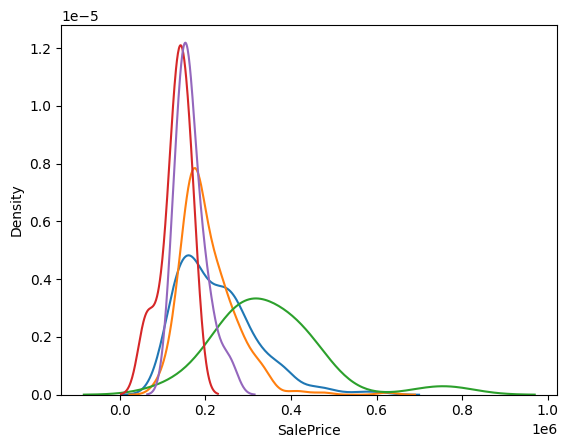

In [ ]:
for category in x_train['FireplaceQu'].dropna().unique():
    sns.distplot(x_train[x_train['FireplaceQu'] == category]['SalePrice'], label=category, hist=False)
plt.show()

/tmp/ipython-input-2735288499.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[x_train['FireplaceQu_imputed'] == category]['SalePrice'], label=category, hist=False)
/tmp/ipython-input-2735288499.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[x_train['Fir

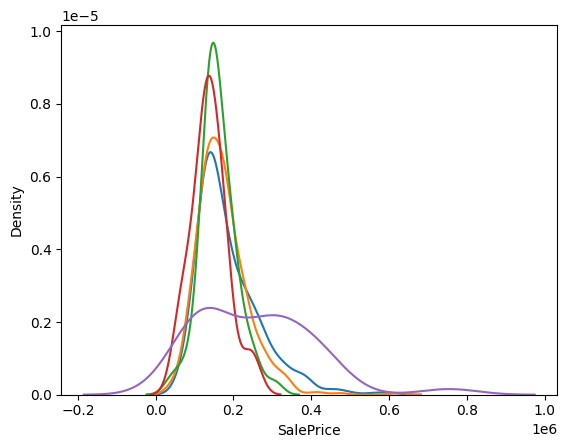

In [ ]:
for category in x_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(x_train[x_train['FireplaceQu_imputed'] == category]['SalePrice'], label=category, hist=False)
plt.show()